/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Lattice instance already exists with id=200.
  warn(msg, IDWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another PlotBase instance already exists with id=1.
  warn(msg, IDWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another PlotBase instance already exists with id=2.
  warn(msg, IDWarning)


Univers 1: Universe
	ID             =	115
	Name           =	
	Geom           =	CSG
	Cells          =	[321, 326, 330, 334]
 (Type: <class 'openmc.universe.Universe'>)
Univers 2: Universe
	ID             =	116
	Name           =	
	Geom           =	CSG
	Cells          =	[322, 327, 331, 335]
 (Type: <class 'openmc.universe.Universe'>)
Univers 3: Universe
	ID             =	117
	Name           =	
	Geom           =	CSG
	Cells          =	[323, 328, 332, 336]
 (Type: <class 'openmc.universe.Universe'>)
Univers 4: Universe
	ID             =	118
	Name           =	
	Geom           =	CSG
	Cells          =	[324, 329, 333, 337]
 (Type: <class 'openmc.universe.Universe'>)
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     

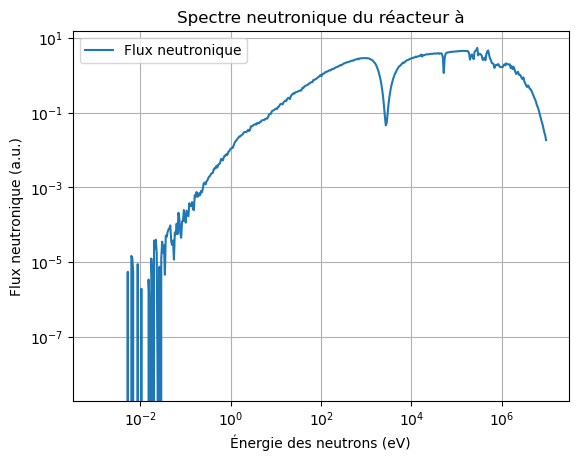

In [26]:
import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# ==========================
# Définition des matériaux
# ==========================

# Combustible MOX (UO2-PuO2)
UGD_fuel = openmc.Material(name='UGD Fuel')
UGD_fuel.add_nuclide('U238', 0.924)
UGD_fuel.add_nuclide('U235', 0.036)
UGD_fuel.add_element('Gd', 0.04)
UGD_fuel.set_density('g/cm3', 10.5)
UGD_fuel.temperature = 1200  # Température en K

def mox_fuel(enrichment):
    """Créer un matériau MOX avec un enrichissement donné en Pu239."""
    mox = openmc.Material()
    mox.add_element('U', 0.91)
    mox.add_nuclide('Pu239', enrichment)
    mox.add_nuclide('Pu240', 0.035)
    mox.add_nuclide('Pu241', 0.005)
    mox.add_nuclide('Pu242', 0.005)
    mox.add_nuclide('O16', 2.00)
    mox.set_density('g/cm3', 10.5)
    mox.temperature = 1200
    return mox

mox_3_6 = mox_fuel(0.08)
mox_2_7 = mox_fuel(0.067)
mox_2_4 = mox_fuel(0.052)

# Caloporteur Sodium
sodium = openmc.Material(name='Sodium')
sodium.add_nuclide('Na23', 1.0)
sodium.set_density('g/cm3', 0.927)
sodium.temperature = 600  # Température en K

# Gainage en zirconium
zirconium_cladding = openmc.Material(name='Zirconium Cladding')
zirconium_cladding.add_element('Zr', 1.0)
zirconium_cladding.set_density('g/cm3', 6.5)
zirconium_cladding.temperature = 900  # Température en K

# Gaz d'Hélium
gas_gap = openmc.Material(name='Helium Gap')
gas_gap.add_element('He', 1.0)
gas_gap.set_density('g/cm3', 0.0001786)
gas_gap.temperature = 900  # Température en K

# Définition des matériaux
materials = openmc.Materials([UGD_fuel, mox_3_6, mox_2_7, mox_2_4, sodium, gas_gap, zirconium_cladding])
materials.export_to_xml()

# ===========================
# Définition de la géométrie
# ===========================

pin_pitch = 1.25984
fuel_radius = openmc.ZCylinder(r=0.39218)
clad_inner_radius = openmc.ZCylinder(r=0.40005)
clad_outer_radius = openmc.ZCylinder(r=0.45720)
#outzone_sodium = openmc.ZCylinder(r=pin_pitch/2)

N = 11  # Nombre de couronnes de crayons
assembly_width = (N-1) * pin_pitch * sqrt(3)
assembly_pitch = assembly_width + 0.5

pin_box = openmc.model.HexagonalPrism(edge_length=pin_pitch/2, boundary_type='reflective')
assembly_box = openmc.model.HexagonalPrism(edge_length=30, boundary_type='reflective')

mox_3_6_cell = openmc.Cell(name='Fuel1', fill=mox_3_6, region=-fuel_radius)
mox_2_7_cell = openmc.Cell(name='Fuel2', fill=mox_2_7, region=-fuel_radius)
mox_2_4_cell = openmc.Cell(name='Fuel3', fill=mox_2_4, region=-fuel_radius)

UGD_cell = openmc.Cell(name='UGd', fill=UGD_fuel, region=-fuel_radius)
guide_tube_cell = openmc.Cell(name='Guide Tube',fill=zirconium_cladding, region=-clad_outer_radius)

gap_3_6_cell = openmc.Cell(name='Helium 3.6 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_7_cell = openmc.Cell(name='Helium 2.7 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_4_cell = openmc.Cell(name='Helium 2.4 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_Ugd_cell = openmc.Cell(name='Helium Ugd Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)

clad_3_6_cell = openmc.Cell(name='Cladding 3.6', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_7_cell = openmc.Cell(name='Cladding 2.7', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_4_cell = openmc.Cell(name='Cladding 2.4', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_Ugd_cell = openmc.Cell(name='Cladding Ugd', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)

sodium_inner_3_6_cell = openmc.Cell(name='Coolant 3.6 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_7_cell = openmc.Cell(name='Coolant 2.7 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_4_cell = openmc.Cell(name='Coolant 2.4 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_Ugd_cell = openmc.Cell(name='Coolant Ugd inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_GT_cell = openmc.Cell(name='Coolant GT inner', fill=sodium, region=+clad_outer_radius)

sodium_outer_cell = openmc.Cell(name='Coolant outer', fill=sodium)

sodium_universe = openmc.Universe(cells=[sodium_outer_cell])
guide_tube_universe = openmc.Universe(cells=[guide_tube_cell,sodium_inner_GT_cell])

mox_3_6_universe = openmc.Universe(cells=[mox_3_6_cell, gap_3_6_cell, clad_3_6_cell,sodium_inner_3_6_cell])
mox_2_7_universe = openmc.Universe(cells=[mox_2_7_cell, gap_2_7_cell, clad_2_7_cell,sodium_inner_2_7_cell])
mox_2_4_universe = openmc.Universe(cells=[mox_2_4_cell, gap_2_4_cell, clad_2_4_cell,sodium_inner_2_4_cell])
UGD_universe = openmc.Universe(cells=[UGD_cell, gap_Ugd_cell, clad_Ugd_cell,sodium_inner_Ugd_cell])

lattice = openmc.HexLattice(lattice_id=200)
lattice.center = (0.0, 0.0)
lattice.pitch = [pin_pitch]
lattice.outer = sodium_universe
lattice.universes = [
    ([mox_2_4_universe] + [mox_2_7_universe] * 9) * 6,
    ([UGD_universe] + [mox_3_6_universe] * 8 ) * 6,
    ([mox_3_6_universe] * 4 + [UGD_universe] + [mox_3_6_universe] * 3) * 6,
    ([mox_3_6_universe] * 7) * 6,
    ([mox_3_6_universe] * 3 + [guide_tube_universe] + [mox_3_6_universe] * 2) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] * 4) * 6,
    ([mox_3_6_universe] * 3 + [UGD_universe]) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] + [mox_3_6_universe]) * 6,
    ([mox_3_6_universe] + [mox_3_6_universe]) * 6,
    [mox_3_6_universe] * 6,
    [guide_tube_universe]
]
for i, universe in enumerate([mox_3_6_universe, mox_2_7_universe, mox_2_4_universe, UGD_universe]):
    print(f"Univers {i+1}: {universe} (Type: {type(universe)})")
    
assembly_cell = openmc.Cell(fill=lattice, region=-assembly_box)
root_universe = openmc.Universe(cells=[assembly_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

# ===========================
# Définition de la physique
# ===========================

source = openmc.Source()
source.space = openmc.stats.Point(
    (0, -pin_pitch, 0.0)  # Point
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=0.988, b=2.249)

settings = openmc.Settings()
settings.batches = 100
settings.inactive = 10
settings.particles = 10000
settings.source = source
settings.run_mode = 'eigenvalue'
settings.temperature = {'method': 'interpolation', 'range': (300, 1200)} # Interpolation des XS pour les températures inexistantes dans l'ENDF/B-VII.1
settings.export_to_xml()

# ===========================
# Vérification de la géométrie
# ===========================

plot_xy = openmc.Plot(plot_id=1)
plot_xy.filename = 'plot_xy'
plot_xy.origin = [0, 0, 0]
plot_xy.width = [6, 6]
plot_xy.pixels = [400, 400]
plot_xy.color_by = 'material'

plot_yz = openmc.Plot(plot_id=2)
plot_yz.filename = 'plot_yz'
plot_yz.basis = 'yz'
plot_yz.origin = [0, 0, 0]
plot_yz.width = [40, 40]
plot_yz.pixels = [400, 400]
plot_yz.color_by = 'material'

# Instantiate a Plots collection, add plots, and export to XML
plot_file = openmc.Plots((plot_xy, plot_yz))
plot_file.export_to_xml()


tallies = openmc.Tallies()

# Tally du spectre neutronique
energy_bins = np.logspace(-3, 7, num=500)  # Gamme d'énergie en eV
energy_filter = openmc.EnergyFilter(energy_bins)
spectrum_tally = openmc.Tally(name='Spectre neutronique')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']
tallies.append(spectrum_tally)

# Tally de l'absorption neutronique dans le sodium
sodium_filter = openmc.MaterialFilter(sodium)
absorption_tally = openmc.Tally(name='Absorption Sodium')
absorption_tally.filters = [sodium_filter]
absorption_tally.scores = ['absorption']
tallies.append(absorption_tally)

tallies.export_to_xml()

# ===========================
# Exécution de la simulation OpenMC
# ===========================

openmc.run()

# ===========================
# Analyse des résultats
# ===========================

# Chargement des résultats
sp = openmc.StatePoint('statepoint.100.h5')

# Extraction des résultats des tallies
spectrum_tally = sp.get_tally(name='Spectre neutronique')
flux = spectrum_tally.mean.flatten()
absorption_tally = sp.get_tally(name='Absorption Sodium')
absorption = absorption_tally.mean.flatten()

# Tracé du spectre neutronique
plt.figure()
plt.loglog(energy_bins[:-1], flux, label='Flux neutronique')
plt.xlabel('Énergie des neutrons (eV)')
plt.ylabel('Flux neutronique (a.u.)')
plt.legend()
plt.grid()
plt.title('Spectre neutronique du réacteur à')
plt.savefig('spectre neutronique 100%.png')
plt.show()


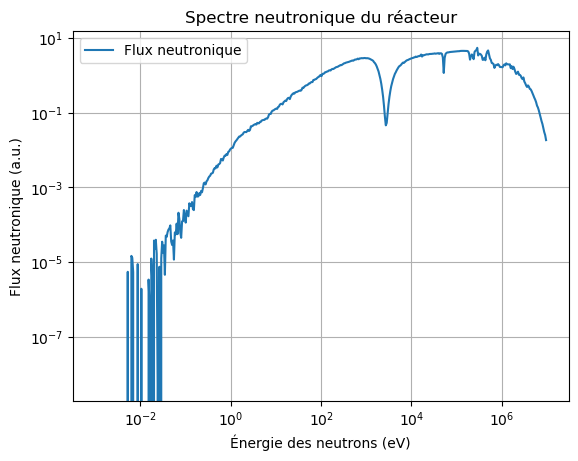

In [27]:
# Chargement des résultats
sp = openmc.StatePoint('statepoint.100.h5')

# Extraction des résultats des tallies
spectrum_tally = sp.get_tally(name='Spectre neutronique')
flux = spectrum_tally.mean.flatten()
absorption_tally = sp.get_tally(name='Absorption Sodium')
absorption = absorption_tally.mean.flatten()

# Tracé du spectre neutronique
plt.figure()
plt.loglog(energy_bins[:-1], flux, label='Flux neutronique')
plt.xlabel('Énergie des neutrons (eV)')
plt.ylabel('Flux neutronique (a.u.)')
plt.legend()
plt.grid()
plt.title('Spectre neutronique du réacteur')
plt.savefig('spectre neutronique 100%.png')
plt.show()